In [1]:
# import libraries 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [2]:
# load the dataset

# Load dataset

data_path = "creditcard.csv"

df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Basic info

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

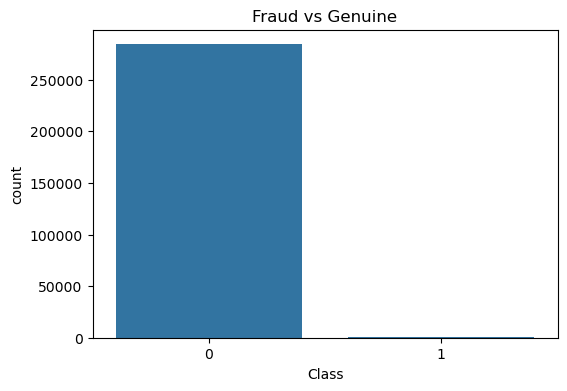

In [4]:
# visualization

plt.figure(figsize=(6,4))

sns.countplot(x=df["Class"])

plt.title("Fraud vs Genuine")
plt.show()

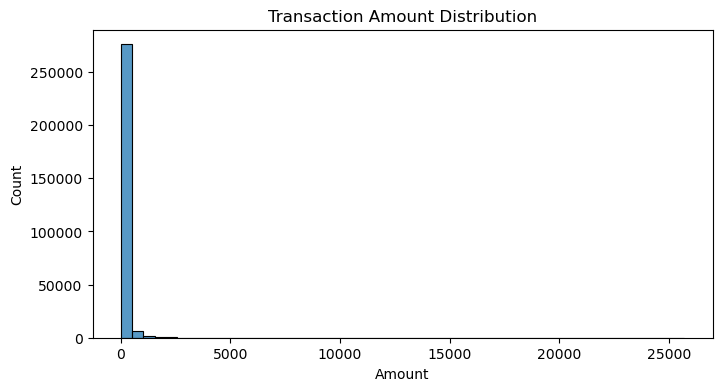

In [5]:
#Transaction amount distribution

plt.figure(figsize=(8,4))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()


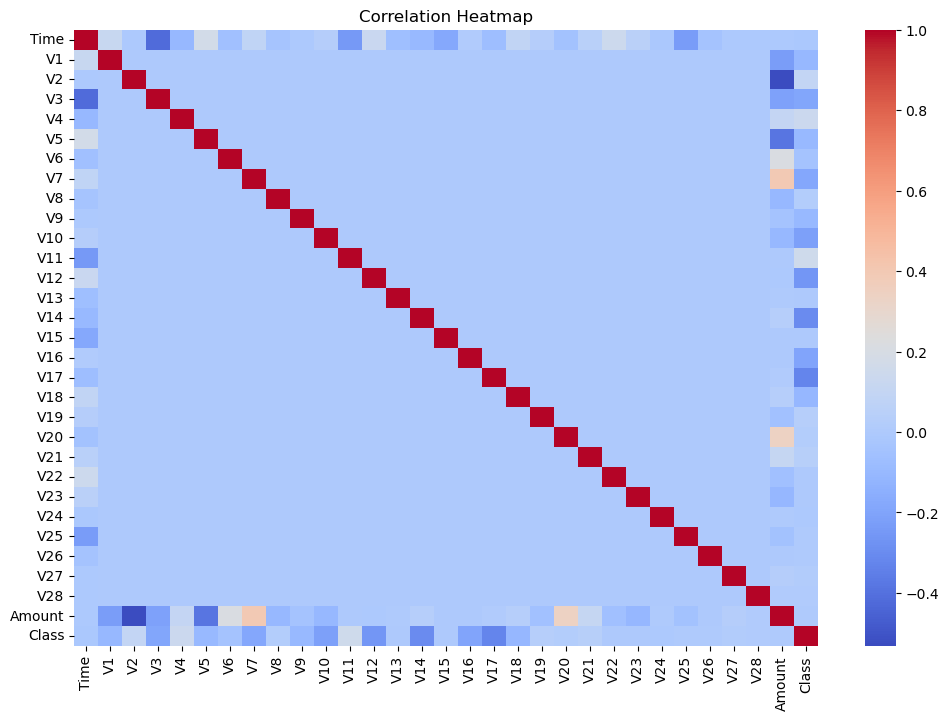

In [6]:
#Correlation heatmap

plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [7]:
#Feature Engineering

X = df.drop("Class", axis=1)
y = df["Class"]

print(X.shape, y.shape)



(284807, 30) (284807,)


In [8]:
#Normalize data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.996583,-0.694242,-0.044075,1.672773,0.973366,-0.245117,0.347068,0.193679,0.082637,0.331128,...,0.326118,-0.024923,0.382854,-0.176911,0.110507,0.246585,-0.392170,0.330892,-0.063781,0.244964
1,-1.996583,0.608496,0.161176,0.109797,0.316523,0.043483,-0.061820,-0.063700,0.071253,-0.232494,...,-0.089611,-0.307377,-0.880077,0.162201,-0.561131,0.320694,0.261069,-0.022256,0.044608,-0.342475
2,-1.996562,-0.693500,-0.811578,1.169468,0.268231,-0.364572,1.351454,0.639776,0.207373,-1.378675,...,0.680975,0.337632,1.063358,1.456320,-1.138092,-0.628537,-0.288447,-0.137137,-0.181021,1.160686
3,-1.996562,-0.493325,-0.112169,1.182516,-0.609727,-0.007469,0.936150,0.192071,0.316018,-1.262503,...,-0.269855,-0.147443,0.007267,-0.304777,-1.941027,1.241904,-0.460217,0.155396,0.186189,0.140534
4,-1.996541,-0.591330,0.531541,1.021412,0.284655,-0.295015,0.071999,0.479302,-0.226510,0.744326,...,0.529939,-0.012839,1.100011,-0.220123,0.233250,-0.395202,1.041611,0.543620,0.651816,-0.073403


In [9]:
#Handle Class Imbalance (SMOTE)

print("Before SMOTE")

print(y.value_counts())


smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X_scaled,
    y
)


print("After SMOTE")

print(y_resampled.value_counts())

Before SMOTE
Class
0    284315
1       492
Name: count, dtype: int64
After SMOTE
Class
0    284315
1    284315
Name: count, dtype: int64


In [10]:
# Train test split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print(X_train.shape, X_test.shape)

(454904, 30) (113726, 30)


In [11]:
#Logistic regression model

log_model = LogisticRegression(
    max_iter=500,
    n_jobs=-1
)

log_model.fit(
    X_train,
    y_train
)

y_pred_log = log_model.predict(X_test)

In [12]:
# Random forest model

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(X_test)

In [15]:
#Evaluation Function 

def evaluate_model(y_true, y_pred, name):

    print("\n======================")
    print("Model:", name)
    print("======================")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.title(name)
    plt.show()


Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     56863
           1       0.97      0.92      0.95     56863

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726

Precision: 0.9735095654753078
Recall: 0.9235355151856216
F1: 0.9478643046016948


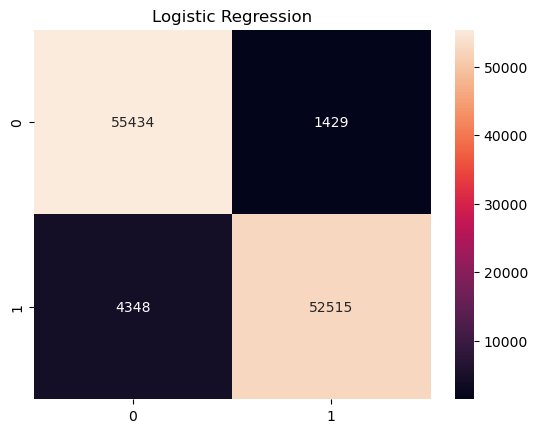


Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

Precision: 0.9997714325901962
Recall: 1.0
F1: 0.9998857032328401


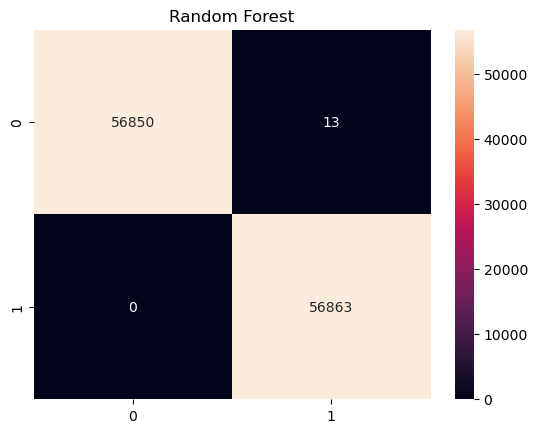

In [17]:
evaluate_model(
    y_test,
    y_pred_log,
    "Logistic Regression"
)

evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)

In [18]:
import pickle

with open("fraud_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved")

Saved
